# Genfit — B⁺ → π⁺π⁺π⁻ isobárico: um toy, vários starts

Gere **um único toy** e ajuste a mesma amostra repetidamente, mudando `start_values` antes de cada fit. Modelo idêntico ao notebook `notebooks/data_analyses/24_b2pipipi_isobar_self_closure_no_cp.ipynb`: seis componentes, coeficientes cartesianos, sem CP, eficiência ou fundo. A referência ρ(770) fica fixa em 1+0i; massas, larguras e raios também ficam fixos.

Execute todas as células em ordem com o ambiente do projeto (incluindo pandas, matplotlib e um kernel Jupyter). Os padrões são 5.000 eventos e 10 ajustes; altere a configuração para aumentar a estatística. As sementes independentes tornam toy e starts reproduzíveis.

In [9]:
from pathlib import Path
import sys

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'src/dalitzplotfitter').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Abra o notebook dentro do repositório DalitzPlotFitter.')
sys.path.insert(0, str(ROOT / 'src'))
from IPython.display import display
from time import perf_counter
import numpy as np
import pandas as pd
import jax.numpy as jnp
import matplotlib.pyplot as plt

from dataclasses import dataclass

from dalitzplotfitter import (
    DecayChannel,
    DecayModel,
    FitSession,
    GounarisSakurai,
    Parameter,
    RealImag,
    RelativisticBreitWigner,
    Resonance,
    enable_x64,
    generate_signal_toy,
)

enable_x64()

SEED = 20260905
N_EVENTS = 100_000
TOY_METHOD = "accept-reject"
NORMALIZATION_METHOD = "gauss-legendre"

channel = DecayChannel("B+", ("pi+", "pi+", "pi-"))
M_PI = float(channel.daughter_masses[0])

print("Toy size:", N_EVENTS)
print("Toy method:", TOY_METHOD)
print("Normalization:", NORMALIZATION_METHOD)

N_FITS = 500
START_SEED = SEED + 1
START_SIGMA = 0.30  # desvio absoluto de x e y em torno da verdade
NCALL = 20_000
STRATEGY = 2
TOLERANCE = 1e-4
DELTA_NLL_TOL = 1e-3  # critério numérico de concordância entre mínimos
assert N_EVENTS > 0 and N_FITS >= 2 and START_SIGMA > 0

Toy size: 100000
Toy method: accept-reject
Normalization: gauss-legendre


## Modelo gerador
Coeficientes e dinâmica reutilizados do estudo isobárico de fechamento existente. As duas partículas π⁺ são tratadas pelo modelo do canal.

In [10]:
TRUTH_COEFFICIENTS = {
    "rho770":    dict(x= 1.000, y= 0.000),
    "omega782":  dict(x= 0.091, y=-0.007),
    "f2_1270":   dict(x= 0.291, y= 0.204),
    "rho1450":   dict(x=-0.223, y= 0.191),
    "rho3_1690": dict(x= 0.073, y=-0.045),
    "sigma":     dict(x=-0.485, y= 0.284),
}

def truth_coefficient(name):
    p = TRUTH_COEFFICIENTS[name]
    return RealImag(p["x"], p["y"])


@dataclass(frozen=True)
class PaperSigmaPole:
    # LHCb Eq. (16): A_sigma(m) = 1 / (s_sigma - m^2)
    def __call__(self, mass, context):
        m = jnp.asarray(mass)
        pole = jnp.asarray(context.pole_mass) - 1j * jnp.asarray(context.pole_width)
        s_sigma = pole**2
        return 1.0 / (s_sigma - m**2)


def isobar_components(coefficient_factory):
    return [
        Resonance(
            "rho770", (0, 2), coefficient_factory("rho770"),
            mass=0.7708, width=0.1534, spin=1,
            lineshape=GounarisSakurai(),
            resonance_radius=4.0, parent_radius=4.0,
        ),
        Resonance(
            "omega782", (0, 2), coefficient_factory("omega782"),
            mass=0.78265, width=0.00849, spin=1,
            lineshape=RelativisticBreitWigner(),
            resonance_radius=4.0, parent_radius=4.0,
        ),
        Resonance(
            "f2_1270", (0, 2), coefficient_factory("f2_1270"),
            mass=1.2755, width=0.1867, spin=2,
            resonance_radius=4.0, parent_radius=4.0,
        ),
        Resonance(
            "rho1450", (0, 2), coefficient_factory("rho1450"),
            mass=1.465, width=0.400, spin=1,
            resonance_radius=4.0, parent_radius=4.0,
        ),
        Resonance(
            "rho3_1690", (0, 2), coefficient_factory("rho3_1690"),
            mass=1.6888, width=0.161, spin=3,
            resonance_radius=4.0, parent_radius=4.0,
        ),
        Resonance(
            "sigma", (0, 2), coefficient_factory("sigma"),
            mass=0.563, width=0.350, spin=0,
            lineshape=PaperSigmaPole(),
            resonance_radius=4.0, parent_radius=4.0,
        ),
    ]


generator = DecayModel(
    channel,
    isobar_components(truth_coefficient),
    normalize_components=True,
    normalization_method=NORMALIZATION_METHOD,
)

print("Generator normalization points:", generator.normalization_sample.size)

INFO DalitzPlotFitter normalization: narrow resonance band(s) detected (m13: m0=0.782650 GeV, Gamma=8.490 MeV; m23: m0=0.782650 GeV, Gamma=8.490 MeV); using adaptive Gauss-Legendre normalization.
Generator normalization points: 2080469


## Gerar o toy uma única vez
Esta célula fica fora do loop de ajustes; todos os fits usam exatamente os mesmos eventos e a mesma normalização.

In [11]:
toy = generate_signal_toy(
    generator,
    N_EVENTS,
    seed=SEED,
    method=TOY_METHOD,
    include_momenta=False,
)

print("Generated events:", toy.size)
print("Toy method:", TOY_METHOD)
print("weights:", np.unique(np.asarray(toy.weights)))
print("momenta retained:", toy.p1 is not None)

Generated events: 100000
Toy method: accept-reject
weights: [1.]
momenta retained: False


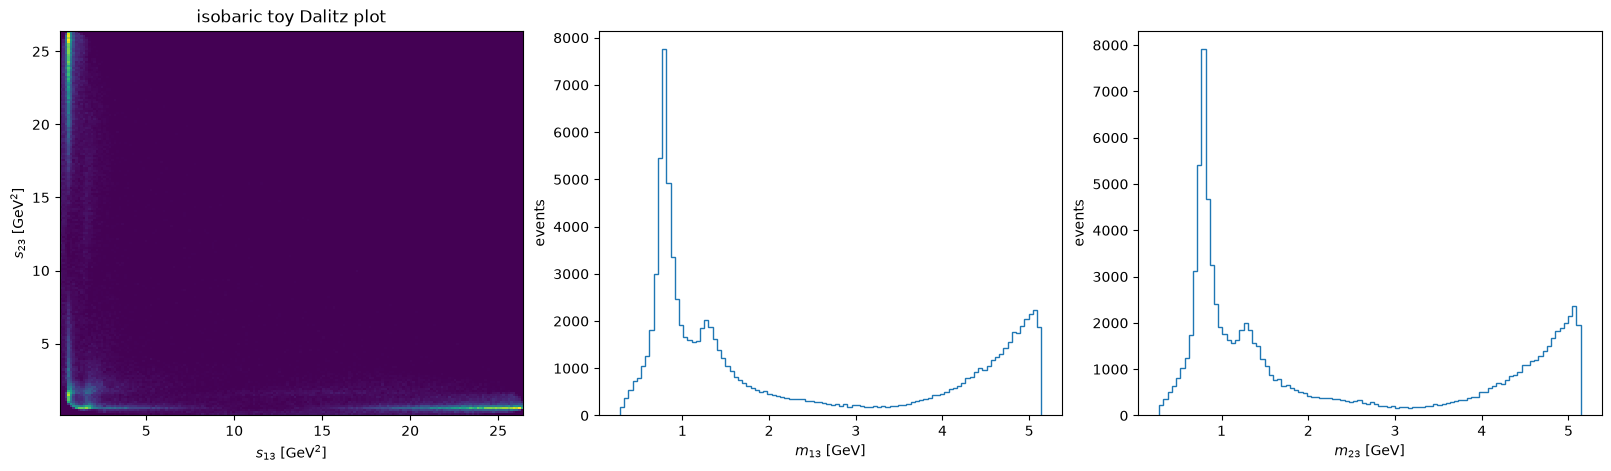

In [12]:
# Toy Dalitz plot and invariant-mass projections before any fit.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), constrained_layout=True)

axes[0].hist2d(
    np.asarray(toy.s13),
    np.asarray(toy.s23),
    bins=180,
)
axes[0].set_xlabel(r"$s_{13}$ [GeV$^2$]")
axes[0].set_ylabel(r"$s_{23}$ [GeV$^2$]")
axes[0].set_title("isobaric toy Dalitz plot")

for ax, values, label in [
    (axes[1], np.sqrt(np.asarray(toy.s13)), r"$m_{13}$"),
    (axes[2], np.sqrt(np.asarray(toy.s23)), r"$m_{23}$"),
]:
    ax.hist(values, bins=100, histtype="step")
    ax.set_xlabel(label + " [GeV]")
    ax.set_ylabel("events")

plt.show()

## Modelo de ajuste
Somente os dez coeficientes cartesianos não referenciais são livres.

In [13]:
def floating_coefficient(name):
    truth = TRUTH_COEFFICIENTS[name]
    reference = name == "rho770"
    return RealImag(
        Parameter.coefficient(
            f"{name}.x",
            truth["x"],
            owner=name,
            fixed=reference,
            step=0.01,
        ),
        Parameter.coefficient(
            f"{name}.y",
            truth["y"],
            owner=name,
            fixed=reference,
            step=0.01,
        ),
    )


fit_model = DecayModel(
    channel,
    isobar_components(floating_coefficient),
    normalize_components=True,
    normalization_method=NORMALIZATION_METHOD,
)

session = FitSession(fit_model, toy)

print("Number of fit parameters:", len(session.parameters))
print("Free parameters:", sum(not p.fixed for p in session.parameters))
for parameter in session.parameters:
    print(
        f"{parameter.name:20s} "
        f"start={float(parameter.value): .6f} "
        f"fixed={parameter.fixed}"
    )

Number of fit parameters: 12
Free parameters: 10
rho770.x             start= 1.000000 fixed=True
rho770.y             start= 0.000000 fixed=True
omega782.x           start= 0.091000 fixed=False
omega782.y           start=-0.007000 fixed=False
f2_1270.x            start= 0.291000 fixed=False
f2_1270.y            start= 0.204000 fixed=False
rho1450.x            start=-0.223000 fixed=False
rho1450.y            start= 0.191000 fixed=False
rho3_1690.x          start= 0.073000 fixed=False
rho3_1690.y          start=-0.045000 fixed=False
sigma.x              start=-0.485000 fixed=False
sigma.y              start= 0.284000 fixed=False


## Starts independentes e reproduzíveis
Cada start é sorteado em torno da verdade com largura `START_SIGMA`, sem usar o resultado do ajuste anterior. A referência fixa não entra no dicionário. O uso da verdade como centro é uma escolha deste teste simples; não representa uma busca global exaustiva.


Cada execução cria `genfit/logs/<data UTC>_<id>/`, com um `.log` por fit (starts, saída do minimizador, resultado e traceback em caso de exceção), `config.json`, `starts.csv`, `summary.csv` e `parameters.csv`. O resumo é atualizado após cada fit; consulte `valid`, `exception` e `log_file` para investigar falhas.


In [14]:
free_parameters = tuple(p for p in session.parameters if not p.fixed)
truth_values = {p.name: float(p.value) for p in session.parameters}
rng = np.random.default_rng(START_SEED)
starts = [
    {p.name: float(truth_values[p.name] + rng.normal(0, START_SIGMA))
     for p in free_parameters}
    for _ in range(N_FITS)
]
assert len({tuple(s.items()) for s in starts}) == N_FITS
starts_table = pd.DataFrame(starts).rename_axis('fit_id')
display(starts_table)
truth_nll = float(session.objective(truth_values))
print(f'NLL na verdade geradora: {truth_nll:.6f}')

,omega782.x,omega782.y,f2_1270.x,f2_1270.y,rho1450.x,rho1450.y,rho3_1690.x,rho3_1690.y,sigma.x,sigma.y
fit_id,,,,,,,,,,
0,0.241749,-0.122138,0.534609,-0.070515,-0.236086,0.449812,0.371532,0.382253,-0.534465,0.428955
1,-0.312971,-0.021339,0.111989,-0.056520,-0.366324,0.298341,0.379612,0.642962,-0.719463,0.394515
2,0.315112,0.261491,0.856246,0.437698,0.347994,0.414155,0.063495,-0.087406,-0.453773,-0.007044
3,0.115948,-0.249547,0.002909,-0.058741,-0.169407,0.140649,-0.079130,-0.285135,-0.152160,0.337011
4,-0.059551,-0.092367,0.595006,0.271837,0.550472,0.082273,-0.278738,0.333257,-0.178080,0.667313
...,...,...,...,...,...,...,...,...,...,...
495,0.525906,-0.802025,0.415723,0.137265,0.022456,0.059231,0.019366,-0.396487,-0.202820,0.289307
496,0.128638,-0.537566,0.832250,0.133782,0.282202,-0.572768,-0.063060,0.213524,-0.370077,0.420667
497,0.253389,0.010781,0.479328,-0.226299,-0.119047,0.408467,-0.004926,0.167596,-0.323027,0.042320


INFO DalitzPlotFitter normalization: narrow resonance band(s) detected (m13: m0=0.782650 GeV, Gamma=8.490 MeV; m23: m0=0.782650 GeV, Gamma=8.490 MeV); using adaptive Gauss-Legendre normalization.
NLL na verdade geradora: 421332.813712


In [15]:
from contextlib import redirect_stdout, redirect_stderr
from datetime import datetime, timezone
import json
import traceback
from uuid import uuid4

# Uma pasta nova a cada execução desta célula, sem sobrescrever logs anteriores.
run_id = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S_%fZ') + '_' + uuid4().hex[:8]
log_dir = ROOT / 'genfit' / 'logs' / run_id
log_dir.mkdir(parents=True, exist_ok=False)
config = dict(seed=SEED, start_seed=START_SEED, n_events=N_EVENTS,
              n_fits=N_FITS, start_sigma=START_SIGMA, ncall=NCALL,
              strategy=STRATEGY, tolerance=TOLERANCE,
              delta_nll_tol=DELTA_NLL_TOL, toy_method=TOY_METHOD,
              normalization_method=NORMALIZATION_METHOD,
              truth_values=truth_values, starts=starts)
(log_dir / 'config.json').write_text(
    json.dumps(config, indent=2, ensure_ascii=False), encoding='utf-8')
starts_table.to_csv(log_dir / 'starts.csv')
print(f'Logs desta execução: {log_dir}')

results = []
summary_rows = []
parameter_rows = []
for fit_id, start_values in enumerate(starts):
    t0 = perf_counter()
    log_path = log_dir / f'fit_{fit_id:03d}.log'
    with log_path.open('w', encoding='utf-8', buffering=1) as log:
        with redirect_stdout(log), redirect_stderr(log):
            print(f'fit_id={fit_id}')
            print('start_values=' + json.dumps(start_values, sort_keys=True))
            print('Configuração completa em config.json')
            try:
                result = session.fit(
                    start_values=dict(start_values), simplex=False, strategy=STRATEGY,
                    hesse=True, tolerance=TOLERANCE, ncall=NCALL, verbose=2,
                )
                print(result)
                session.print_result(result)
                failure = None
            except Exception as exc:
                traceback.print_exc()
                result = None
                failure = repr(exc)
            finally:
                print(f'elapsed_seconds={perf_counter()-t0:.6f}')
    if result is None:
        results.append(None)
        summary_rows.append(dict(fit_id=fit_id, valid=False, nll=np.nan,
                                 seconds=perf_counter()-t0, exception=failure,
                                 log_file=str(log_path)))
        pd.DataFrame(summary_rows).to_csv(log_dir / 'summary.csv', index=False)
        print(f'Fit {fit_id}: falhou: {failure}; log: {log_path.name}', flush=True)
        continue
    results.append(result)
    summary_rows.append(dict(
        fit_id=fit_id, valid=bool(result.valid), nll=float(result.fval),
        edm=float(result.fmin.edm), nfcn=int(result.nfcn),
        accurate_covariance=bool(result.fmin.has_accurate_covar),
        call_limit=bool(result.fmin.has_reached_call_limit),
        seconds=perf_counter()-t0, exception='', log_file=str(log_path),
    ))
    values = session.result_values(result)
    for p in session.parameters:
        error = 0.0 if p.fixed else float(result.errors[p.name])
        parameter_rows.append(dict(
            fit_id=fit_id, parameter=p.name, fixed=p.fixed,
            truth=truth_values[p.name], start=start_values.get(p.name, p.value),
            value=values[p.name], error=error,
            pull=(values[p.name]-truth_values[p.name])/error if error > 0 else np.nan,
        ))
    pd.DataFrame(summary_rows).to_csv(log_dir / 'summary.csv', index=False)
    pd.DataFrame(parameter_rows).to_csv(log_dir / 'parameters.csv', index=False)
    print(f'Fit {fit_id}: valid={result.valid}, NLL={result.fval:.6f}, '
          f'EDM={result.fmin.edm:.2e}', flush=True)

summary = pd.DataFrame(summary_rows).set_index('fit_id')
parameters = pd.DataFrame(parameter_rows)
valid = summary['valid'] & np.isfinite(summary['nll'])
best_id = int(summary.loc[valid, 'nll'].idxmin()) if valid.any() else None
summary['delta_nll'] = summary['nll'] - summary.loc[best_id, 'nll'] if best_id is not None else np.nan
summary['same_minimum'] = valid & (summary['delta_nll'].abs() <= DELTA_NLL_TOL)
summary.to_csv(log_dir / 'summary.csv')
parameters.to_csv(log_dir / 'parameters.csv', index=False)
display(summary)
print(f'Ajustes válidos: {valid.sum()}/{N_FITS}; melhor fit: {best_id}')
print('O tempo do primeiro fit pode incluir compilação JAX.')

Logs desta execução: /home/juan-leite/Work/DalitzPlotFitter/genfit/logs/20260909T212328_298341Z_202b795b
Fit 0: valid=True, NLL=421326.665253, EDM=7.41e-09
Fit 1: valid=True, NLL=422605.024014, EDM=9.54e-10
Fit 2: valid=True, NLL=421326.665253, EDM=1.41e-08
Fit 3: valid=True, NLL=421326.665253, EDM=1.00e-08
Fit 4: valid=True, NLL=421326.665253, EDM=4.35e-09
Fit 5: valid=True, NLL=421326.665253, EDM=4.04e-09
Fit 6: valid=True, NLL=421326.665253, EDM=2.26e-10
Fit 7: valid=True, NLL=421326.665253, EDM=3.77e-09
Fit 8: valid=True, NLL=421326.665253, EDM=2.35e-08
Fit 9: valid=True, NLL=421326.665253, EDM=3.49e-08
Fit 10: valid=True, NLL=421326.665253, EDM=1.62e-08
Fit 11: valid=True, NLL=421326.665253, EDM=2.59e-10
Fit 12: valid=True, NLL=421326.665253, EDM=4.08e-08
Fit 13: valid=True, NLL=421326.665253, EDM=1.52e-08
Fit 14: valid=True, NLL=421326.665253, EDM=3.85e-10
Fit 15: valid=True, NLL=421326.665253, EDM=2.73e-08
Fit 16: valid=True, NLL=421326.665253, EDM=5.92e-08
Fit 17: valid=True, N

,valid,nll,edm,nfcn,accurate_covariance,call_limit,seconds,exception,log_file,delta_nll,same_minimum
fit_id,,,,,,,,,,,
0,True,421326.665253,7.409109e-09,597,True,False,1.197430,,/home/juan-leite/Work/DalitzPlotFitter/genfit/...,7.392373e-09,True
1,True,422605.024014,9.536679e-10,657,True,False,0.721657,,/home/juan-leite/Work/DalitzPlotFitter/genfit/...,1.278359e+03,False
2,True,421326.665253,1.413197e-08,595,True,False,0.664026,,/home/juan-leite/Work/DalitzPlotFitter/genfit/...,1.420267e-08,True
3,True,421326.665253,1.001549e-08,598,True,False,0.652366,,/home/juan-leite/Work/DalitzPlotFitter/genfit/...,1.001172e-08,True
4,True,421326.665253,4.353739e-09,585,True,False,0.639667,,/home/juan-leite/Work/DalitzPlotFitter/genfit/...,4.423782e-09,True
...,...,...,...,...,...,...,...,...,...,...,...
495,True,421326.665253,1.167900e-09,636,True,False,0.894621,,/home/juan-leite/Work/DalitzPlotFitter/genfit/...,1.164153e-09,True
496,True,421326.665253,2.517746e-08,572,True,False,0.845440,,/home/juan-leite/Work/DalitzPlotFitter/genfit/...,2.514571e-08,True
497,True,421326.665253,1.958098e-09,579,True,False,0.823379,,/home/juan-leite/Work/DalitzPlotFitter/genfit/...,1.979060e-09,True


Ajustes válidos: 500/500; melhor fit: 371
O tempo do primeiro fit pode incluir compilação JAX.


## Comparação dos mínimos e fechamento
ΔNLL é relativo ao melhor ajuste **válido**. Concordância de NLL não garante unicidade dos coeficientes. Os pulls abaixo são diagnósticos de um único toy; estes fits correlacionados não constituem um ensemble para medir viés ou cobertura.

,fit_id,fixed,truth,start,value,error,pull
parameter,,,,,,,
rho770.x,371,True,1.000,1.000000,1.000000,0.000000,NaN
rho770.y,371,True,0.000,0.000000,0.000000,0.000000,NaN
omega782.x,371,False,0.091,0.358390,0.095743,0.003304,1.435517
omega782.y,371,False,-0.007,0.111112,-0.006462,0.003726,0.144383
f2_1270.x,371,False,0.291,0.085309,0.294112,0.003514,0.885624
f2_1270.y,371,False,0.204,0.273230,0.205624,0.003399,0.477724
rho1450.x,371,False,-0.223,0.026178,-0.230778,0.004653,-1.671613
rho1450.y,371,False,0.191,0.776648,0.189522,0.003583,-0.412547
rho3_1690.x,371,False,0.073,-0.142226,0.074815,0.002931,0.619344


Fit fractions (physical)
component                    fraction [%]
rho770                            57.3898
omega782                           0.5285
f2_1270                            7.3908
rho1450                            5.1179
rho3_1690                          0.4423
sigma                             18.5137
sum                               89.3830


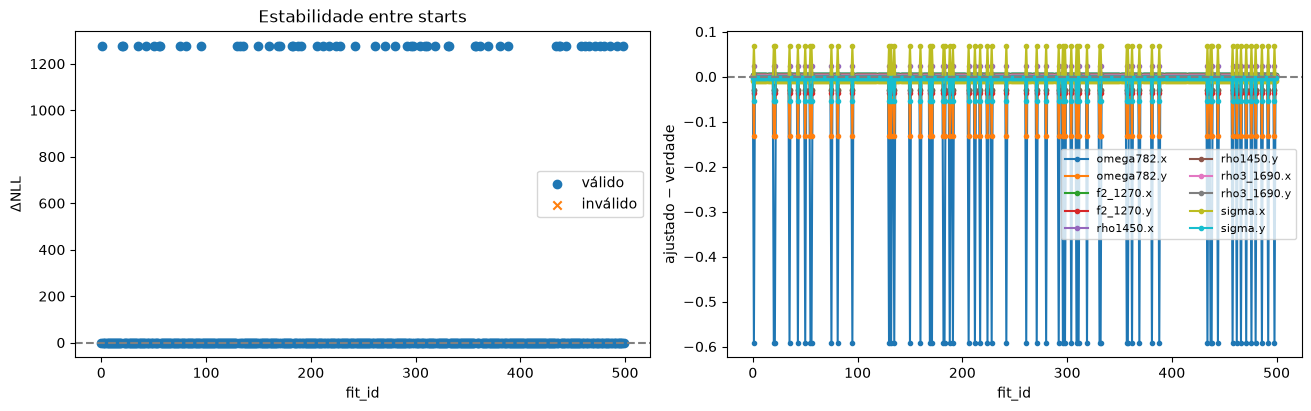

In [16]:
if best_id is None:
    print('Nenhum mínimo válido. Inspecione summary antes de interpretar o fechamento.')
else:
    best_result = results[best_id]
    display(parameters.loc[parameters.fit_id == best_id].set_index('parameter'))
    session.print_fit_fractions(best_result, precision=4)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
    for is_valid, label, marker in [(True, 'válido', 'o'), (False, 'inválido', 'x')]:
        rows = summary.loc[summary.valid == is_valid]
        axes[0].scatter(rows.index, rows.delta_nll, label=label, marker=marker)
    axes[0].axhline(DELTA_NLL_TOL, color='grey', linestyle='--')
    axes[0].set(xlabel='fit_id', ylabel='ΔNLL', title='Estabilidade entre starts')
    axes[0].legend()
    for p in free_parameters:
        rows = parameters.loc[parameters.parameter == p.name]
        axes[1].plot(rows.fit_id, rows.value - rows.truth, '.-', label=p.name)
    axes[1].axhline(0, color='grey', linestyle='--')
    axes[1].set(xlabel='fit_id', ylabel='ajustado − verdade')
    axes[1].legend(fontsize=8, ncol=2)
    plt.show()

## Como interpretar
- Verifique validade, EDM, covariância e limite de chamadas antes de comparar coeficientes.
- Starts convergindo ao mesmo NLL e aos mesmos coeficientes indicam estabilidade para esta amostra e região inicial.
- Mínimos diferentes devem ser inspecionados; aumente `N_FITS` ou `START_SIGMA` para explorar mais pontos.
- A verdade não precisa minimizar a NLL deste toy: há flutuações estatísticas. Um pull isolado grande não demonstra falha.
- Este teste não valida a precisão da integração de normalização nem a cobertura estatística; esses estudos exigem testes próprios.

Os objetos `toy`, `starts_table`, `results`, `summary` e `parameters` ficam disponíveis para inspeção.